# Reconstruct and Deconstruct the VIX Index

Here we present an analysis of the CBOE VIX volatility index.  We begin by reconstructing the VIX index calculation using daily ^SPX option chain data downloaded from OptionsDX. We reproduce the known result that the VIX index tends to overpredict the market volatility during non-volatile market periods.  We then extend the standard VIX index calculation by implementing a Merton jump model into the pricing formula in order to test whether market jumps --- specifically insurance against market jumps being baked into options pricing --- is, at least in part, the reason for the discrepancy between VIX the measured market volatility.  We decompose our modified 'VIX' calculation into diffusive and jump volatility components and show that by stripping off the jump component we arrive at a better correspondence between the model and the market volatility.

In [1]:
from datetime import datetime, timezone, date
import glob
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py7zr
from scipy.optimize import minimize
from scipy.special import ndtr, gammaln
from scipy.stats import norm
from tqdm import tqdm
import yfinance as yf

In [2]:
# ── Configuration ──

# Path to your OptionsDX data — can contain .7z archives and/or extracted CSVs
DATA_DIR = Path("option_chains")
EXTRACT_DIR = Path("option_chains")

RISK_FREE_RATE = 0.05  # simply assume constant, VIX is insensitive to interest rate

# OptionsDX column names
COL_QUOTE_DATE   = "[QUOTE_DATE]"
COL_EXPIRE_DATE  = "[EXPIRE_DATE]"
COL_STRIKE       = "[STRIKE]"
COL_UNDERLYING   = "[UNDERLYING_LAST]"
COL_C_BID        = "[C_BID]"
COL_C_ASK        = "[C_ASK]"
COL_P_BID        = "[P_BID]"
COL_P_ASK        = "[P_ASK]"
COL_DTE          = "[DTE]"

## 1. Extract and load options data downloaded from OptionsDX

We first extract the 7zip data files downloaded from OptionsDX to standard CSV files. This data includes daily closing options pricing for ^SPX, which we will use to reproduce the ^VIX calculation.

In [3]:
def extract_all_7z(data_dir: Path, extract_dir: Path) -> None:
    """Extract all .7z files found under data_dir into extract_dir."""
    extract_dir.mkdir(parents=True, exist_ok=True)
    archives = list(data_dir.glob("**/*.7z"))
    if not archives:
        print("No .7z files found — assuming CSVs are already extracted.")
        return
    for archive in sorted(archives):
        print(f"Extracting {archive.name} …")
        with py7zr.SevenZipFile(archive, mode="r") as z:
            z.extractall(path=extract_dir)
    print(f"Done. CSVs are in {extract_dir}")

extract_all_7z(DATA_DIR, EXTRACT_DIR)

Extracting spx_eod_2018-uqawfl.7z …
Extracting spx_eod_2019-chxexe.7z …
Extracting spx_eod_2020-wh6jt7.7z …
Extracting spx_eod_2021-n4uqkm.7z …
Extracting spx_eod_2021q3-kgzold.7z …
Extracting spx_eod_2021q4-r3h0dx.7z …
Extracting spx_eod_2022q1-ff0r18.7z …
Extracting spx_eod_2022q2-bxgzw0.7z …
Extracting spx_eod_2022q3-1f2afi.7z …
Extracting spx_eod_2022q4-dmme3k.7z …
Extracting spx_eod_2023q1-cfph7w.7z …
Extracting spx_eod_2023q2-kdxt36.7z …
Extracting spx_eod_2023q3-w9b0jk.7z …
Extracting spx_eod_2023q4-ai4uc9.7z …
Done. CSVs are in option_chains


Now read time series data files into single Pandas DataFrame

In [4]:
def load_optionsdx(csv_dir: Path) -> pd.DataFrame:
    """
    Load all OptionsDX CSVs from csv_dir (and DATA_DIR itself, in case
    some were pre-extracted there).
    Returns a single DataFrame with parsed date columns.
    """
    patterns = [
        str(csv_dir / "**" / "*.txt"),
        str(DATA_DIR / "**" / "*.txt"),
    ]
    files = sorted(set(f for p in patterns for f in glob.glob(p, recursive=True)))
    if not files:
        raise FileNotFoundError(
            f"No TXT files found under {csv_dir} or {DATA_DIR}. "
            "Check DATA_DIR / EXTRACT_DIR."
        )
    print(f"Loading {len(files)} TXT file(s) …")
    chunks = []
    for f in tqdm(files):
        df = pd.read_csv(
            f,
            parse_dates=[COL_QUOTE_DATE, COL_EXPIRE_DATE],
            low_memory=False,
            skipinitialspace=True,
        )
        # Normalise column names (strip whitespace)
        df.columns = df.columns.str.strip()
        chunks.append(df)
    data = pd.concat(chunks, ignore_index=True)
    print(f"Loaded {len(data):,} rows spanning "
          f"{data[COL_QUOTE_DATE].min().date()} – {data[COL_QUOTE_DATE].max().date()}")
    return data

## 2. Build options chains

Build options chain for a given quote and expiration date pair. Returns (strike, call, put) tuples that will be used to calculate the VIX index.  Also define a convenience function 'available_expirations' to check the available expiration dates in the dataset for a given quote date.

In [5]:
def build_chain_from_df(
    df: pd.DataFrame,
    as_of_date: str | date,
    expiration_date: str | date,
    strike_window_pct: float | None = None,
) -> list[tuple[float, float | None, float | None]]:
    """
    Extract the options chain for a single (quote_date, expiration_date) pair
    from an OptionsDX wide-format DataFrame.

    Returns a list of (strike, call_mid, put_mid) tuples, sorted by strike.
    Midpoints are (bid + ask) / 2; None if both bid and ask are zero/NaN.
    """
    as_of = pd.Timestamp(as_of_date)
    expiry = pd.Timestamp(expiration_date)

    mask = (
        (df[COL_QUOTE_DATE].dt.normalize() == as_of.normalize()) &
        (df[COL_EXPIRE_DATE].dt.normalize() == expiry.normalize())
    )
    subset = df[mask].copy()

    if subset.empty:
        raise ValueError(
            f"No data found for quote_date={as_of_date}, expiration={expiration_date}. "
            f"Available expirations on that date: "
            f"{sorted(df[df[COL_QUOTE_DATE].dt.normalize()==as_of.normalize()][COL_EXPIRE_DATE].dt.date.unique())}"
        )

    # Optionally filter to a strike window around the underlying
    if strike_window_pct is not None:
        spot = subset[COL_UNDERLYING].iloc[0]
        lo, hi = spot * (1 - strike_window_pct), spot * (1 + strike_window_pct)
        subset = subset[(subset[COL_STRIKE] >= lo) & (subset[COL_STRIKE] <= hi)]

    def mid(bid_col, ask_col, row):
        b, a = row[bid_col], row[ask_col]
        if pd.isna(b) or pd.isna(a) or (b <= 0 and a <= 0):
            return None
        # If one side is zero, use the other
        if b <= 0:
            return a
        if a <= 0:
            return b
        return (b + a) / 2

    chain = []
    for _, row in subset.iterrows():
        K = row[COL_STRIKE]
        c_mid = mid(COL_C_BID, COL_C_ASK, row)
        p_mid = mid(COL_P_BID, COL_P_ASK, row)
        chain.append((K, c_mid, p_mid))

    chain.sort(key=lambda x: x[0])
    return chain


def available_expirations(df: pd.DataFrame, as_of_date: str | date) -> list[date]:
    """List all expiration dates available in the data for a given quote date."""
    as_of = pd.Timestamp(as_of_date)
    mask = df[COL_QUOTE_DATE].dt.normalize() == as_of.normalize()
    return sorted(df[mask][COL_EXPIRE_DATE].dt.date.unique())

## 3. Calculate VIX index

Define functions for calculating the VIX index from ^SPX option chains. The VIX index is given by:

$VIX = 100 \sqrt{\bar{\sigma}_T^2}$

where

$\bar{\sigma}_T^2 = \frac{2}{T} \sum_i \frac{\Delta K_i}{K_i^2} e^{rT} Q(K_i) - \frac{1}{T}(\frac{F}{K_0} - 1)^2$,

$Q(K_i)$ is the mid-quote, the average of the highest bid and lowest ask of the relevant out-of-the-money option, and the forward price, $F$, is

$F = K_0 + e^{rT}[C(K_0) - P(K_0)]$,

obtained from put-call parity for the strike price $K_0$ that minimizes $|C(K_0) - P(K_0)|$.

In [6]:
def forward_price(chain: list[tuple], r: float, tau: float) -> float:
    """Forward price via put-call parity at the strike where |C - P| is minimised."""
    best_strike, best_diff, best_c, best_p = None, float("inf"), None, None
    for K, c, p in chain:
        if c is not None and p is not None:
            diff = abs(c - p)
            if diff < best_diff:
                best_strike, best_diff, best_c, best_p = K, diff, c, p
    if best_strike is None:
        raise ValueError("No strikes with both call and put prices found.")
    return best_strike + np.exp(r * tau) * (best_c - best_p)


def chain_lookup(chain: list[tuple], K: float):
    for strike, call_mid, put_mid in chain:
        if strike == K:
            return call_mid, put_mid
    return None, None


def compute_variance(chain: list[tuple], F: float, r: float, tau: float) -> tuple[float, float]:
    """CBOE VIX variance integral over OTM options."""
    strikes = sorted(set(c[0] for c in chain))
    K0 = max(k for k in strikes if k < F)  # largest strike below F

    total = 0.0
    n = len(strikes)
    for i, K in enumerate(strikes):
        call_mid, put_mid = chain_lookup(chain, K)

        if K < K0:
            Q = put_mid
        elif K > K0:
            Q = call_mid
        else:  # K == K0: average of call and put
            Q = (call_mid + put_mid) / 2 if (call_mid and put_mid) else (call_mid or put_mid)

        if Q is None:
            continue

        if i == 0:
            dK = strikes[1] - strikes[0]
        elif i == n - 1:
            dK = strikes[-1] - strikes[-2]
        else:
            dK = (strikes[i + 1] - strikes[i - 1]) / 2

        total += (dK / K**2) * np.exp(r * tau) * Q

    variance = (2 / tau) * total - (1 / tau) * ((F / K0) - 1) ** 2
    return variance, K0

def calculate_vix(
    df: pd.DataFrame,
    as_of_date: str,
    near_expiration: str,
    next_expiration: str,
    strike_window_pct: float | None = 0.10,
    r: float = RISK_FREE_RATE,
    quiet: bool = False,
) -> float:
    """
    Calculate VIX-style implied volatility from OptionsDX data.

    Parameters
    ----------
    df               : full OptionsDX DataFrame (from load_optionsdx)
    as_of_date       : the pricing date, e.g. "2024-01-12"
    near_expiration  : near-term expiration, e.g. "2024-01-19"
    next_expiration  : next-term expiration, e.g. "2024-02-16"
    strike_window_pct: fraction around spot to include (None = all strikes)
    r                : risk-free rate (continuously compounded, annualised)
    """
    as_of_dt = pd.Timestamp(as_of_date).replace(tzinfo=timezone.utc)

    T1 = (pd.Timestamp(near_expiration, tz="UTC") - as_of_dt).total_seconds() / (365 * 86400)
    T2 = (pd.Timestamp(next_expiration,  tz="UTC") - as_of_dt).total_seconds() / (365 * 86400)
    T30 = 30 / 365

    if T1 <= 0 or T2 <= 0:
        raise ValueError("Expiration dates must be after as_of_date.")

    chain1 = build_chain_from_df(df, as_of_date, near_expiration, strike_window_pct)
    chain2 = build_chain_from_df(df, as_of_date, next_expiration,  strike_window_pct)

    F1 = forward_price(chain1, r, T1)
    F2 = forward_price(chain2, r, T2)

    var1, K0_1 = compute_variance(chain1, F1, r, T1)
    var2, K0_2 = compute_variance(chain2, F2, r, T2)

    if not quiet:
        print(f"Near  ({near_expiration}): T={T1*365:.1f}d  F={F1:.2f}  K0={K0_1}  var={var1:.6f}")
        print(f"Next  ({next_expiration}): T={T2*365:.1f}d  F={F2:.2f}  K0={K0_2}  var={var2:.6f}")

    N1, N2, N30 = T1 * 365, T2 * 365, 30
    weighted = (
        T1 * var1 * (N2 - N30) / (N2 - N1)
        + T2 * var2 * (N30 - N1) / (N2 - N1)
    )
    vix = 100 * np.sqrt(weighted * 365 / 30)
    return vix

## 6. Rolling VIX across all dates in the dataset

We now calculate a rolling VIX index across all dates in our dataset.

In [7]:
def auto_select_expirations(
    expirations: list[date], as_of: date, target_dte: int = 30
) -> tuple[date, date] | None:
    """
    Auto-select near/next expirations that straddle target_dte.
    Returns None if not possible.
    """
    as_of_ts = pd.Timestamp(as_of)
    dtes = [(e, (pd.Timestamp(e) - as_of_ts).days) for e in expirations]
    # Must have at least 7 DTE
    dtes = [(e, d) for e, d in dtes if d >= 7]
    below = [(e, d) for e, d in dtes if d <= target_dte]
    above = [(e, d) for e, d in dtes if d > target_dte]
    if not below or not above:
        return None
    near = max(below, key=lambda x: x[1])[0]   # closest below 30
    nxt  = min(above, key=lambda x: x[1])[0]   # closest above 30
    return near, nxt


def rolling_vix(
    df: pd.DataFrame,
    strike_window_pct: float = 0.10,
    r: float = RISK_FREE_RATE,
) -> pd.DataFrame:
    """Compute VIX for every trading day in the dataset."""
    all_dates = sorted(df[COL_QUOTE_DATE].dt.date.unique())
    results = []
    for as_of in tqdm(all_dates):
        expiries = available_expirations(df, as_of)
        pair = auto_select_expirations(expiries, as_of)
        if pair is None:
            continue
        near, nxt = pair
        try:
            vix = calculate_vix(
                df, str(as_of), str(near), str(nxt),
                strike_window_pct=strike_window_pct, r=r,
                quiet=True,
            )
            results.append({"date": as_of, "near": near, "next": nxt, "vix": vix})
        except Exception as e:
            print(f"Skipping {as_of}: {e}")

    return pd.DataFrame(results).set_index("date")

In [8]:
raw = load_optionsdx(EXTRACT_DIR)
vix_series = rolling_vix(raw)

Loading 72 TXT file(s) …


100%|██████████████████████████████████████████████████████████████████████| 72/72 [00:33<00:00,  2.13it/s]


Loaded 10,763,286 rows spanning 2018-01-02 – 2023-12-29


 67%|████████████████████████████████████████████▎                     | 1006/1500 [12:36<06:12,  1.33it/s]

Skipping 2022-01-17: No strikes with both call and put prices found.


...

 71%|███████████████████████████████████████████████                   | 1070/1500 [13:25<05:46,  1.24it/s]

Skipping 2022-04-15: No strikes with both call and put prices found.


 83%|██████████████████████████████████████████████████████▊           | 1247/1500 [15:40<03:05,  1.36it/s]

Skipping 2022-12-26: No strikes with both call and put prices found.


100%|██████████████████████████████████████████████████████████████████| 1500/1500 [18:51<00:00,  1.33it/s]


## 7. Calculate Market Volatility from SPX

As a comparison, we will calculate the realized market volatility from ^GSPC daily pricing data downloaded from yfinance.  We shift the rolling realized volatility calculation by 21 days (one trading month) to account for the fact that VIX is a forward looking index, over a 1 month period in our calculation.

In [9]:
def realized_volatility() -> pd.DataFrame:
    spx = yf.download("^GSPC", start="2018-01-01", end="2024-01-01")
    log_returns = np.log(spx["Close"] / spx["Close"].shift(1))
    realized_vol = log_returns.rolling(window=21).std() * np.sqrt(252) * 100
    realized_vol_forward = realized_vol.shift(-21)
    return realized_vol_forward

vol = realized_volatility()

[*********************100%***********************]  1 of 1 completed


## 8. Graphical Comparison of Calculated VIX, "True" VIX, and Realized Volatility

[*********************100%***********************]  1 of 1 completed


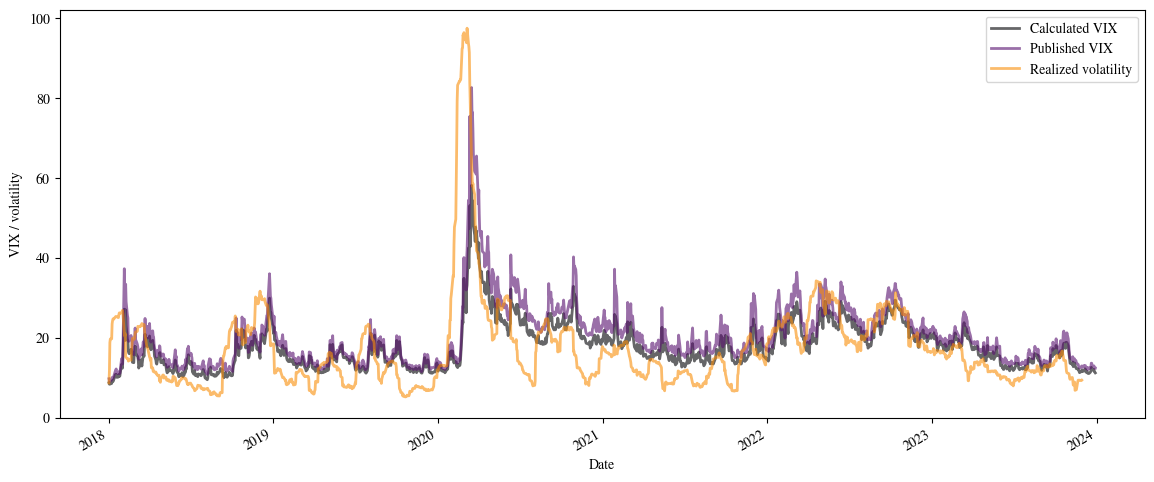

In [10]:
# Extract published VIX index values over our time period from yfinance
vix_data = yf.download("^VIX", start="2018-01-01", end="2024-01-01")

cmap = plt.cm.inferno

ax = vix_series["vix"].plot(
    figsize=(14, 6),
    color=cmap(0.0),
    lw=2,
    alpha=0.6,
    label="Calculated VIX"
)
vix_data["Close"].plot(
    ax=ax,
    color=cmap(0.25),
    lw=2,
    alpha=0.6,
    label="Published VIX"
)
vol.plot(
    ax=ax,
    color=cmap(0.75),
    lw=2,
    alpha=0.6,
    label="Realized volatility"
)
ax.set_ylim(bottom=0)
ax.set_ylabel("VIX / volatility")
ax.set_xlabel("Date")
ax.legend(["Calculated VIX", "Published VIX", "Realized volatility"])
vix_series.to_csv("vix_calc.csv")
vix_data["Close"].to_csv("vix_true.csv")
vol.to_csv("realized_vol.csv")

We show a comparison of the time series data for our reconstructed VIX index from OptionsDX daily chains, the true published VIX values, and the realized volatility calculated from historical ^SPX pricing. Excellent agreement between the reconstructed and published VIX values highlights our ability to accurately reproduce the VIX index, even from daily closing data.

The comparison relative to the realized market volatility highlights a well-known trend: the VIX index tends to overestimate the true market volatility, at least during non-volatile market periods. This is often explained by the fact that the options used to calculate VIX generally have some insurance against market jumps priced into them.  In the (common) instance where these volatile market jumps do not materialize, the VIX index then overpredicts the true diffusive market volatility.

We now proceed to test this interpretation by implementing a Merton jump model into the standard VIX calculation, creating a modified 'VIX-like' index that includes both a diffusive and a jump volatility component.

## 9. Calibrating the Merton model

After incorporating the Merton jump model the volatility estimate analagous to the VIX index above is expressed as

$\bar{\sigma_{T,Merton}}^2 = \sigma^2 + \lambda(m^2 + \delta^2)$

We now calibrate the parameters $\sigma,\lambda,m,\delta$ from the Merton model in order to decompose the diffusive and jump volatility terms.

$\sigma$ -> diffusive volatility

$\lambda$ -> jump frequency

$m$ -> jump size

$\delta$ -> variation in the jump size

We calibrate these parameters against our dataset by evaluating which parameter values are consistent with a given day's option prices. Through experimenting with our dataset, we found that the model was underspecified by the data when attempting to optimize all four parameters on a daily basis.  Instead, we first calibrate $m$ and $\delta$ against a broad set of dates and then fix these parameters at the resulting values.  Then using these fixed $m$ and $\delta$, we optimize $\sigma$ and $\lambda$ on a daily basis against the option prices in our dataset.

In [11]:
def merton_call_prices_vec(
    K, S0: float, r: float, T: float,
    sigma: float, lam: float, m: float, delta: float,
    n_terms: int = 50,
) -> np.ndarray:
    """
    Merton (1976) closed-form call prices for an array of strikes at once.
    """
    K = np.atleast_1d(np.asarray(K, dtype=float))
    k = math.exp(m + 0.5 * delta**2) - 1.0          # Equation (7)
 
    # Poisson weights in log space (stable, no factorial overflow)
    n = np.arange(n_terms)
    log_w = -lam * T + n * math.log(lam * T + 1e-300) - gammaln(n + 1)
    keep = log_w > math.log(1e-14)
    keep[: min(6, n_terms)] = True                  # same n>5 cutoff rule as before
    n = n[keep]
    w = np.exp(log_w[keep])                         # (M,)
 
    S_n = S0 * (1 + k) ** n * math.exp(-lam * k * T)     # (M,)
    sig_n = np.sqrt(sigma**2 + n * delta**2 / T)          # (M,)
    sqrtT = math.sqrt(T)
 
    d1 = (np.log(S_n[:, None] / K[None, :]) + (r + 0.5 * sig_n[:, None] ** 2) * T) \
         / (sig_n[:, None] * sqrtT)                       # (M, N)
    d2 = d1 - sig_n[:, None] * sqrtT
    bs = S_n[:, None] * ndtr(d1) - K[None, :] * math.exp(-r * T) * ndtr(d2)
    return w @ bs        

def chain_to_call_equivalents(
    chain: list[tuple], F: float, K0: float, r: float, T: float,
) -> tuple[list[float], list[float]]:
    """
    Convert an OTM chain (as returned by build_chain_from_df) into
    call-equivalent market prices C*(K_i).
    """
    strikes_out, prices_out = [], []
    for K, call_mid, put_mid in chain:
        if K >= K0:
            if call_mid is not None:
                strikes_out.append(K)
                prices_out.append(call_mid)
        else:
            if put_mid is not None:
                strikes_out.append(K)
                prices_out.append(put_mid + math.exp(-r * T) * (F - K))
    return strikes_out, prices_out

def merton_variance_decomposition(theta_hat: dict) -> dict:
    """Equation (10) of main2.tex, applied to a calibrate_merton fit."""
    sigma, lam, m, delta = theta_hat["sigma"], theta_hat["lam"], theta_hat["m"], theta_hat["delta"]
    diffusive = sigma**2
    jump = lam * (m**2 + delta**2)
    return {"diffusive": diffusive, "jump": jump, "total": diffusive + jump}

def group_by_quote_date(df: pd.DataFrame) -> dict:
    """One-time split of the full OptionsDX frame into {date: sub-DataFrame}."""
    dates = df[COL_QUOTE_DATE].dt.normalize()
    return {ts.date(): sub for ts, sub in df.groupby(dates, sort=True)}

Functions for calibrating fixed values of $m$ and $\delta$

In [12]:
def select_calibration_dates(vix_series: pd.DataFrame, n: int = 25) -> list:
    s = vix_series["vix"].dropna().sort_values()
    idx = np.linspace(0, len(s) - 1, n).round().astype(int)
    return sorted(s.iloc[idx].index.tolist())


def _prepare_day(day_df, as_of, expiration, r, strike_window_pct, weighting):
    as_of_dt = pd.Timestamp(as_of).replace(tzinfo=timezone.utc)
    T = (pd.Timestamp(expiration, tz="UTC") - as_of_dt).total_seconds() / (365 * 86400)
    chain = build_chain_from_df(day_df, as_of, expiration, strike_window_pct)
    S0 = day_df[COL_UNDERLYING].iloc[0]
    F = forward_price(chain, r, T)
    _, K0 = compute_variance(chain, F, r, T)
    strikes, calls = chain_to_call_equivalents(chain, F, K0, r, T)
    K = np.asarray(strikes, float); C = np.asarray(calls, float)
    w = make_calibration_weights(K, C, S0, r, T, scheme=weighting)
    return dict(K=K, C=C, w=w, S0=S0, T=T)

def fit_sigma_lam(
    K: np.ndarray, C: np.ndarray, w: np.ndarray,
    S0: float, r: float, T: float, m: float, delta: float,
    x0=(0.2, 0.5),
    lam_max: float = 20.0,
):
    bounds = [(1e-3, 3.0), (1e-6, lam_max)]
    def objective(x):
        err = merton_call_prices_vec(K, S0, r, T, x[0], x[1], m, delta) - C
        return float(w @ (err * err))
    return minimize(objective, x0, method="L-BFGS-B", bounds=bounds)

def make_calibration_weights(strikes, market_calls, S0, r, T,
                             scheme="vix", rel_floor=0.05):
    K = np.asarray(strikes, dtype=float)
    C = np.asarray(market_calls, dtype=float)

    if scheme == "vix":
        dK = np.empty_like(K)
        dK[1:-1] = (K[2:] - K[:-2]) / 2.0
        dK[0] = K[1] - K[0]
        dK[-1] = K[-1] - K[-2]
        w = dK / K**2
    else:
        raise ValueError(f"Unknown weighting scheme: {scheme!r}")
    return w / w.mean()

def estimate_shared_jump_params(
    df: pd.DataFrame, dates: list,
    r: float = RISK_FREE_RATE, strike_window_pct: float = 0.10,
    weighting: str = "vix",
    m0: float = -0.07, delta0: float = 0.10,
) -> dict:
    by_date = group_by_quote_date(df)
    day_data = []
    for as_of in tqdm(dates, desc="building chains"):
        day_df = by_date.get(pd.Timestamp(as_of).date())
        if day_df is None:
            continue
        expiries = sorted(day_df[COL_EXPIRE_DATE].dt.date.unique())
        pair = auto_select_expirations(expiries, as_of)
        if pair is None:
            continue
        try:
            day_data.append(_prepare_day(day_df, str(as_of), str(pair[0]),
                                         r, strike_window_pct, weighting))
        except Exception as e:
            print(f"Skipping {as_of}: {e}")

    if len(day_data) < 5:
        raise ValueError("Too few usable dates for a pooled jump-size estimate.")

    inner_starts = [(0.2, 0.5)] * len(day_data)

    def outer(x):
        m, delta = x
        total = 0.0
        for i, d in enumerate(day_data):
            res = fit_sigma_lam(d["K"], d["C"], d["w"], d["S0"], r, d["T"],
                                m, delta, x0=inner_starts[i])
            inner_starts[i] = tuple(res.x)
            total += res.fun
        return total

    res = minimize(outer, [m0, delta0], method="Nelder-Mead",
                   options=dict(xatol=1e-3, fatol=1e-10, maxfev=300))
    m_hat, delta_hat = res.x
    print(f"Shared jump-size estimate: m={m_hat:.4f}, delta={delta_hat:.4f} "
          f"(pooled over {len(day_data)} days, outer nfev={res.nfev})")
    return {"m": m_hat, "delta": delta_hat, "result": res, "n_days": len(day_data)}

Functions for day-by-day calibration of $\sigma$ and $\lambda$

In [13]:
def calibrate_merton_restricted(
    chain: list[tuple], F: float, K0: float, S0: float, r: float, T: float,
    m_fixed: float, delta_fixed: float,
    sigma0: float | None = None,
    x0=None,
    weighting: str = "vix",
) -> dict:
    """Same return-dict shape as calibrate_merton, so
    merton_variance_decomposition / validate_against_vix work unchanged."""
    strikes, market_calls = chain_to_call_equivalents(chain, F, K0, r, T)
    if len(strikes) < 3:
        raise ValueError("Not enough usable quotes to calibrate (sigma, lam).")

    if sigma0 is None:
        model_free_var, _ = compute_variance(chain, F, r, T)
        sigma0 = math.sqrt(max(model_free_var, 1e-4))

    K_arr = np.asarray(strikes, float)
    C_arr = np.asarray(market_calls, float)
    w = make_calibration_weights(K_arr, C_arr, S0, r, T, scheme=weighting)

    res = fit_sigma_lam(K_arr, C_arr, w, S0, r, T, m_fixed, delta_fixed,
                        x0=x0 if x0 is not None else (sigma0, 0.5))
    sigma_hat, lam_hat = res.x

    return {
        "sigma": sigma_hat, "lam": lam_hat, "m": m_fixed, "delta": delta_fixed,
        "result": res,
        "strikes": strikes, "market_calls": market_calls,
        "weights": w, "weighting": weighting,
    }

def merton_for_expiration_restricted(
    day_df, as_of_date, expiration_date, m_fixed, delta_fixed,
    r: float = RISK_FREE_RATE, strike_window_pct: float = 0.10,
    x0=None, weighting: str = "vix",
) -> dict:
    as_of_dt = pd.Timestamp(as_of_date).replace(tzinfo=timezone.utc)
    T = (pd.Timestamp(expiration_date, tz="UTC") - as_of_dt).total_seconds() / (365 * 86400)
    chain = build_chain_from_df(day_df, as_of_date, expiration_date, strike_window_pct)
    S0 = day_df[COL_UNDERLYING].iloc[0]
    F = forward_price(chain, r, T)
    _, K0 = compute_variance(chain, F, r, T)

    fit = calibrate_merton_restricted(chain, F, K0, S0, r, T,
                                      m_fixed, delta_fixed,
                                      x0=x0, weighting=weighting)
    decomp = merton_variance_decomposition(fit)
    return {"T": T, "F": F, "K0": K0, "fit": fit, "decomp": decomp}

def rolling_merton_calibration_restricted(
    df: pd.DataFrame, m_fixed: float, delta_fixed: float,
    strike_window_pct: float = 0.10, r: float = RISK_FREE_RATE,
    dates: list | None = None, warm_start: bool = True,
    weighting: str = "vix",
) -> pd.DataFrame:
    by_date = group_by_quote_date(df)
    all_dates = dates if dates is not None else sorted(by_date.keys())
    N30 = 30
    results = []
    x0_near = x0_next = None

    for as_of in tqdm(all_dates):
        day_df = by_date.get(pd.Timestamp(as_of).date())
        if day_df is None:
            continue
        expiries = sorted(day_df[COL_EXPIRE_DATE].dt.date.unique())
        pair = auto_select_expirations(expiries, as_of)
        if pair is None:
            continue
        near, nxt = pair
        try:
            near_result = merton_for_expiration_restricted(
                day_df, str(as_of), str(near), m_fixed, delta_fixed,
                r, strike_window_pct, x0=x0_near, weighting=weighting)
            next_result = merton_for_expiration_restricted(
                day_df, str(as_of), str(nxt), m_fixed, delta_fixed,
                r, strike_window_pct, x0=x0_next, weighting=weighting)
        except Exception as e:
            print(f"Skipping {as_of}: {e}")
            continue

        if warm_start:
            x0_near = near_result["fit"]["result"].x
            x0_next = next_result["fit"]["result"].x

        N1, N2 = near_result["T"] * 365, next_result["T"] * 365
        w_near = (N2 - N30) / (N2 - N1)
        w_next = (N30 - N1) / (N2 - N1)

        blended_diffusive = (
            near_result["T"] * near_result["decomp"]["diffusive"] * w_near
            + next_result["T"] * next_result["decomp"]["diffusive"] * w_next
        ) * 365 / 30
        blended_jump = (
            near_result["T"] * near_result["decomp"]["jump"] * w_near
            + next_result["T"] * next_result["decomp"]["jump"] * w_next
        ) * 365 / 30

        results.append({
            "date": as_of, "near": near, "next": nxt,
            "sigma_near": near_result["fit"]["sigma"],
            "sigma_next": next_result["fit"]["sigma"],
            "lam_near": near_result["fit"]["lam"],
            "lam_next": next_result["fit"]["lam"],
            "merton_diffusive": blended_diffusive,
            "merton_jump": blended_jump,
            "merton_total": blended_diffusive + blended_jump,
            #"validation_gap_near": near_result["validation"]["difference"],
            #"validation_gap_next": next_result["validation"]["difference"],
        })

    return pd.DataFrame(results).set_index("date")

Run parameter calibration

In [14]:
# # Stage 1 (calibrate m, delta once):
pool_dates = select_calibration_dates(vix_series, n=25)
shared = estimate_shared_jump_params(raw, pool_dates, strike_window_pct=0.30, weighting="vix")

# # Stage 2 (calibrate sigma, lambda on daily basis):
merton_series_r = rolling_merton_calibration_restricted(
    raw, m_fixed=shared["m"], delta_fixed=shared["delta"], weighting="vix")

building chains: 100%|█████████████████████████████████████████████████████| 25/25 [00:00<00:00, 88.38it/s]


Shared jump-size estimate: m=-0.1841, delta=0.0960 (pooled over 25 days, outer nfev=273)


 68%|████████████████████████████████████████████▋                     | 1015/1500 [00:19<00:08, 53.91it/s]

Skipping 2022-01-17: No strikes with both call and put prices found.


 69%|█████████████████████████████████████████████▍                    | 1033/1500 [00:19<00:09, 47.40it/s]

...

 72%|███████████████████████████████████████████████▍                  | 1077/1500 [00:20<00:10, 38.81it/s]

Skipping 2022-04-15: No strikes with both call and put prices found.


 84%|███████████████████████████████████████████████████████▏          | 1254/1500 [00:25<00:05, 46.96it/s]

Skipping 2022-12-26: No strikes with both call and put prices found.


100%|██████████████████████████████████████████████████████████████████| 1500/1500 [00:29<00:00, 50.85it/s]


## 10. Visualize results of Merton jump model implementation

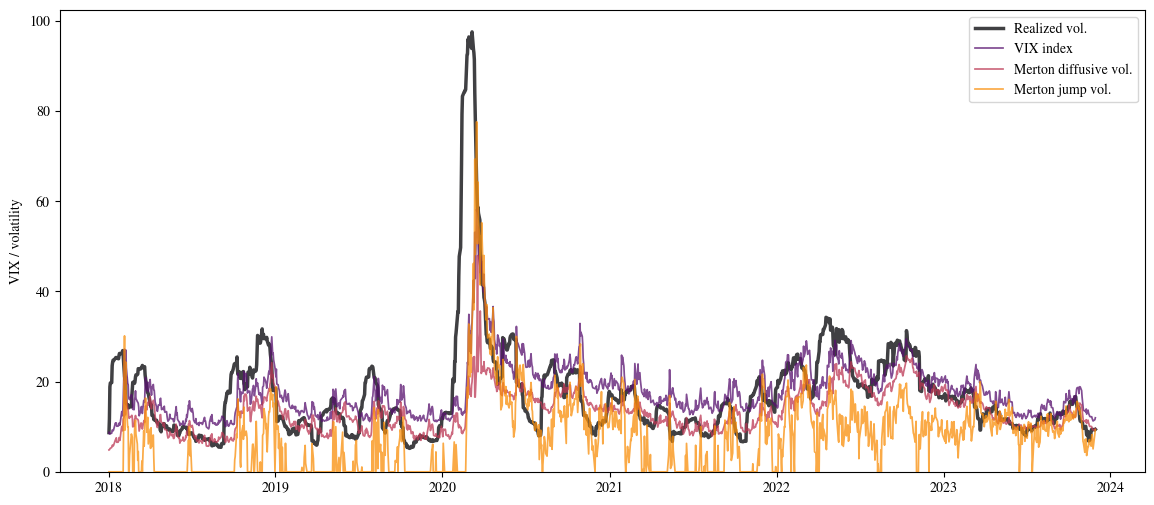

In [15]:
ms = merton_series_r

comparison = pd.DataFrame({
    "vix": vix_series["vix"],
    "merton_diffusive_vol": 100 * np.sqrt(ms["merton_diffusive"]),
        "merton_jump_vol": 100 * np.sqrt(ms["merton_jump"]),
    "merton_total_vol": 100 * np.sqrt(ms["merton_total"]),
    "realized_vol_forward": vol["^GSPC"],
}).dropna()

cmap = plt.cm.inferno

ax = comparison["realized_vol_forward"].plot(
    figsize=(14, 6),
    color=cmap(0.0),
    alpha=0.75,
    lw=2.5,
    zorder=2,
    label="Realized vol.",
)

comparison["vix"].plot(
    ax=ax,
    color=cmap(0.25),
    alpha=0.75,
    lw=1.25,
    zorder=3,
    label="VIX index"
)

comparison["merton_diffusive_vol"].plot(
    ax=ax,
    color=cmap(0.5),
    alpha=0.75,
    lw=1.25,
    zorder=3,
    label="Merton diffusive vol."
)

comparison["merton_jump_vol"].plot(
    ax=ax,
    color=cmap(0.75),
    alpha=0.75,
    lw=1.25,
    zorder=3,
    label="Merton jump vol.",
)

ax.legend()
ax.set_ylim(bottom=0)
ax.set_ylabel("VIX / volatility")
plt.show()

First we show the time series plot analagous to the one shown in the VIX reconstruction.  We show again the realized volatility and the VIX index, but now we also plot the diffusive and jump volatility components from our Merton model calibration.  Compared to the VIX, the Merton diffusive volatility more closely tracks the realized market volatility during non-volatile market periods. This supports our hypothesis above that the VIX index overpredicts the realized volatility do to in-pricing of the fear of market jumps, when we strip out the jump component we see a closer correspondence.

Text(0, 0.5, 'Relative volatility')

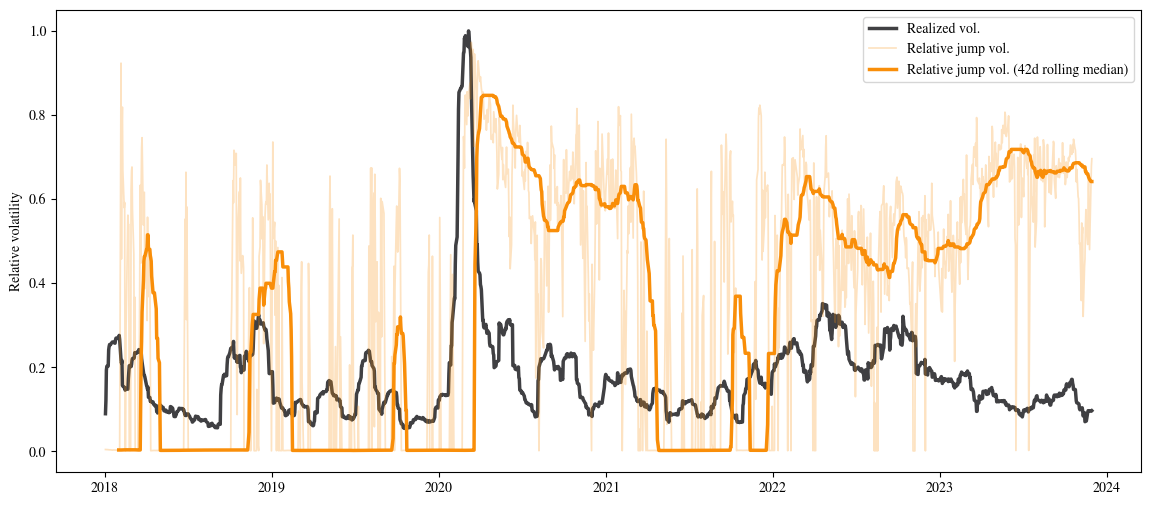

In [16]:
relative_vol = comparison["merton_jump_vol"] / comparison["merton_total_vol"]
realized_vol_norm = comparison["realized_vol_forward"] / comparison["realized_vol_forward"].max()

ax = realized_vol_norm.plot(
    figsize=(14, 6),
    color=cmap(0.0),
    alpha=0.75,
    lw=2.5,
    zorder=2,
    label="Realized vol.",
)

relative_vol.plot(
    ax=ax,
    color=cmap(0.75),
    alpha=0.25,
    lw=1.25,
    zorder=3,
    label="Relative jump vol.",
)

relative_vol.rolling(42, min_periods=21).median().plot(
    ax=ax,
    color=cmap(0.75),
    alpha=1.0,
    lw=2.5,
    zorder=4,
    label="Relative jump vol. (42d rolling median)",
)

ax.legend()

ax.set_ylabel("Relative volatility")

Here we show the relative contribution from the Merton jump volatility (jump vol. / total vol.) in reference to the realized market volatility that has been re-scaled to a maximum of one.  The Merton jump modelling picks up major market events (e.g. the 2020 COVID-19 pandemic), albeit with some delay.